# Five-minute unfiltered Hall-array acquisition and PSD

This notebook records all 36 channels for 300 seconds, converts the received ADC values directly to volts, and computes ensemble averages and PSDs from the board's natural output voltage.

All saved data, plots, ensemble averages, and PSDs use the board's natural output voltage. No DC removal, moving average, smoothing, windowing, or Welch averaging is applied.

**Hardware limitation:** the current camera firmware calls `super_frame(frame, 64)`, so every transmitted frame is already the average of 64 ADC scans. That device-side averaging cannot be undone here without changing and reflashing the firmware.

## 1. Imports and acquisition settings

Run the notebook with an environment containing NumPy, Matplotlib, pySerial, and Jupyter. Change `PORT` if the array appears under another serial-device name. Leave `SAMPLE_RATE_HZ = None` to estimate the transmitted-frame rate from the five-minute capture. If you have independently measured the exact frame rate, enter it instead for the most accurate PSD frequency axis.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import json
import time
import matplotlib.pyplot as plt
import numpy as np
import serial

PORT = "/dev/ttyACM0"
BAUDRATE = 921600
DURATION_S = 5 * 60
SAMPLE_RATE_HZ = None  # None = estimate the output-frame rate from the capture

NUM_CHANNELS = 36
SYNC_BYTES = b"\xAA\x55\xAA\x55"
PAYLOAD_SIZE = NUM_CHANNELS * 2
RAW_SHIFT = 4
V_REF = 5.0
ADC_FULL_SCALE = 1 << 12
VOLTS_PER_COUNT = V_REF / ADC_FULL_SCALE


run_id = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
OUTPUT_DIR = Path("hall_array_output") / run_id
OUTPUT_DIR.mkdir(parents=True, exist_ok=False)
print(f"Results will be written to: {OUTPUT_DIR.resolve()}")

Results will be written to: /home/hamid/SuperHallArray/hall_array_output/20260914T033112Z


## 2. Frame parser and five-minute capture

The parser uses the same byte-accurate synchronization and ADC scaling as the viewer. The serial input buffer is cleared immediately before acquisition so old frames are not included. Stop the cell with the notebook interrupt button if necessary; the serial port is still closed by the `finally` block.

In [2]:
class FrameParser:
    def __init__(self):
        self.buffer = bytearray()

    def feed(self, chunk):
        self.buffer.extend(chunk)
        frames = []
        frame_size = len(SYNC_BYTES) + PAYLOAD_SIZE

        while True:
            sync_index = self.buffer.find(SYNC_BYTES)
            if sync_index < 0:
                keep = len(SYNC_BYTES) - 1
                if len(self.buffer) > keep:
                    del self.buffer[:-keep]
                break
            if len(self.buffer) - sync_index < frame_size:
                del self.buffer[:sync_index]
                break

            payload_start = sync_index + len(SYNC_BYTES)
            payload_end = payload_start + PAYLOAD_SIZE
            wire_values = np.frombuffer(
                bytes(self.buffer[payload_start:payload_end]), dtype="<u2"
            ).copy()
            del self.buffer[:payload_end]
            frames.append(wire_values)

        return frames


def acquire_frames(port, baudrate, duration_s):
    parser = FrameParser()
    wire_frames = []
    arrival_times_s = []

    with serial.Serial(port, baudrate, timeout=0.1) as ser:
        ser.reset_input_buffer()
        start = time.perf_counter()
        next_report = start + 10

        while True:
            now = time.perf_counter()
            if now - start >= duration_s:
                break

            chunk = ser.read(max(ser.in_waiting, 1))
            if chunk:
                parsed = parser.feed(chunk)
                received_at = time.perf_counter() - start
                wire_frames.extend(parsed)
                arrival_times_s.extend([received_at] * len(parsed))

            if now >= next_report:
                elapsed = now - start
                print(
                    f"{elapsed:6.1f}/{duration_s:.0f} s, "
                    f"{len(wire_frames):,} frames received"
                )
                next_report += 10.0

        capture_elapsed_s = time.perf_counter() - start

    if len(wire_frames) < 2:
        raise RuntimeError(
            f"Only {len(wire_frames)} frame(s) were received from {port}. "
            "Check the port, firmware mode, and USB connection."
        )

    return (
        np.asarray(wire_frames, dtype=np.uint16),
        np.asarray(arrival_times_s, dtype=np.float64),
        capture_elapsed_s,
    )


wire_values, arrival_times_s, capture_elapsed_s = acquire_frames(
    PORT, BAUDRATE, DURATION_S
)

# Q4 wire values -> fractional 12-bit ADC counts -> physical output volts.
# This is direct scaling only: no baseline removal and no host-side filtering.
adc_counts = wire_values.astype(np.float64) / (1 << RAW_SHIFT)
voltage_out = adc_counts * VOLTS_PER_COUNT

if SAMPLE_RATE_HZ is None:
    measured_sample_rate_hz = (len(voltage_out) - 1) / (
        arrival_times_s[-1] - arrival_times_s[0]
    )
    sample_rate_hz = measured_sample_rate_hz
    sample_rate_source = "estimated from host arrival time"
else:
    sample_rate_hz = float(SAMPLE_RATE_HZ)
    measured_sample_rate_hz = (len(voltage_out) - 1) / (
        arrival_times_s[-1] - arrival_times_s[0]
    )
    sample_rate_source = "user supplied"

if not np.isfinite(sample_rate_hz) or sample_rate_hz <= 0:
    raise RuntimeError(f"Invalid sample rate: {sample_rate_hz}")

# Frames do not contain device timestamps. Use a uniform time base at the selected
# output-frame rate, as required by the FFT PSD. Arrival times remain in the NPZ file.
time_s = np.arange(len(voltage_out), dtype=np.float64) / sample_rate_hz

print(f"Captured {len(voltage_out):,} frames in {capture_elapsed_s:.3f} s")
print(f"Measured output-frame rate: {measured_sample_rate_hz:.6f} Hz")
print(f"PSD/time-axis rate: {sample_rate_hz:.6f} Hz ({sample_rate_source})")
print(f"Voltage array shape: {voltage_out.shape}")

  10.0/300 s, 334 frames received
  20.0/300 s, 667 frames received
  30.0/300 s, 1,001 frames received
  40.0/300 s, 1,334 frames received
  50.0/300 s, 1,667 frames received
  60.0/300 s, 2,001 frames received
  70.0/300 s, 2,334 frames received
  80.0/300 s, 2,667 frames received
  90.0/300 s, 3,001 frames received
 100.0/300 s, 3,334 frames received
 110.0/300 s, 3,667 frames received
 120.0/300 s, 4,001 frames received
 130.0/300 s, 4,334 frames received
 140.0/300 s, 4,667 frames received
 150.0/300 s, 5,001 frames received
 160.0/300 s, 5,334 frames received
 170.0/300 s, 5,667 frames received
 180.0/300 s, 6,001 frames received
 190.0/300 s, 6,334 frames received
 200.0/300 s, 6,667 frames received
 210.0/300 s, 7,001 frames received
 220.0/300 s, 7,334 frames received
 230.0/300 s, 7,667 frames received
 240.0/300 s, 8,001 frames received
 250.0/300 s, 8,334 frames received
 260.0/300 s, 8,667 frames received
 270.0/300 s, 9,001 frames received
 280.0/300 s, 9,334 frames recei

## 3. Save the natural board-voltage samples

The compressed NPZ is the lossless primary data file and includes the received Q4 words, fractional ADC counts, natural output voltages, a uniform time base, and host arrival times. The CSV is provided for interoperability.

In [3]:
npz_path = OUTPUT_DIR / "hall_array_5min_unfiltered.npz"
np.savez_compressed(
    npz_path,
    time_s=time_s,
    host_arrival_time_s=arrival_times_s,
    voltage_out_v=voltage_out,
    adc_counts=adc_counts,
    wire_q4_values=wire_values,
    sample_rate_hz=np.array(sample_rate_hz),
)

csv_path = OUTPUT_DIR / "hall_array_5min_unfiltered.csv"
csv_data = np.column_stack((time_s, voltage_out))
csv_header = "time_s," + ",".join(
    f"pad_{index:02d}_voltage_out_v" for index in range(1, NUM_CHANNELS + 1)
)
np.savetxt(csv_path, csv_data, delimiter=",", header=csv_header, comments="")

metadata = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "port": PORT,
    "baudrate": BAUDRATE,
    "requested_duration_s": DURATION_S,
    "actual_capture_elapsed_s": capture_elapsed_s,
    "number_of_frames": len(voltage_out),
    "number_of_channels": NUM_CHANNELS,
    "measured_output_frame_rate_hz": measured_sample_rate_hz,
    "psd_sample_rate_hz": sample_rate_hz,
    "sample_rate_source": sample_rate_source,
    "volts_per_adc_count": VOLTS_PER_COUNT,
    "host_filtering": "none",
    "baseline_subtracted": False,
    "firmware_note": "Current camera firmware averages 64 ADC scans per transmitted frame.",
}
metadata_path = OUTPUT_DIR / "metadata.json"
metadata_path.write_text(json.dumps(metadata, indent=2) + "\n", encoding="utf-8")

print(f"Saved {npz_path}")
print(f"Saved {csv_path}")
print(f"Saved {metadata_path}")

Saved hall_array_output/20260914T033112Z/hall_array_5min_unfiltered.npz
Saved hall_array_output/20260914T033112Z/hall_array_5min_unfiltered.csv
Saved hall_array_output/20260914T033112Z/metadata.json


## 4. Plot and save natural voltage versus time for all 36 pads

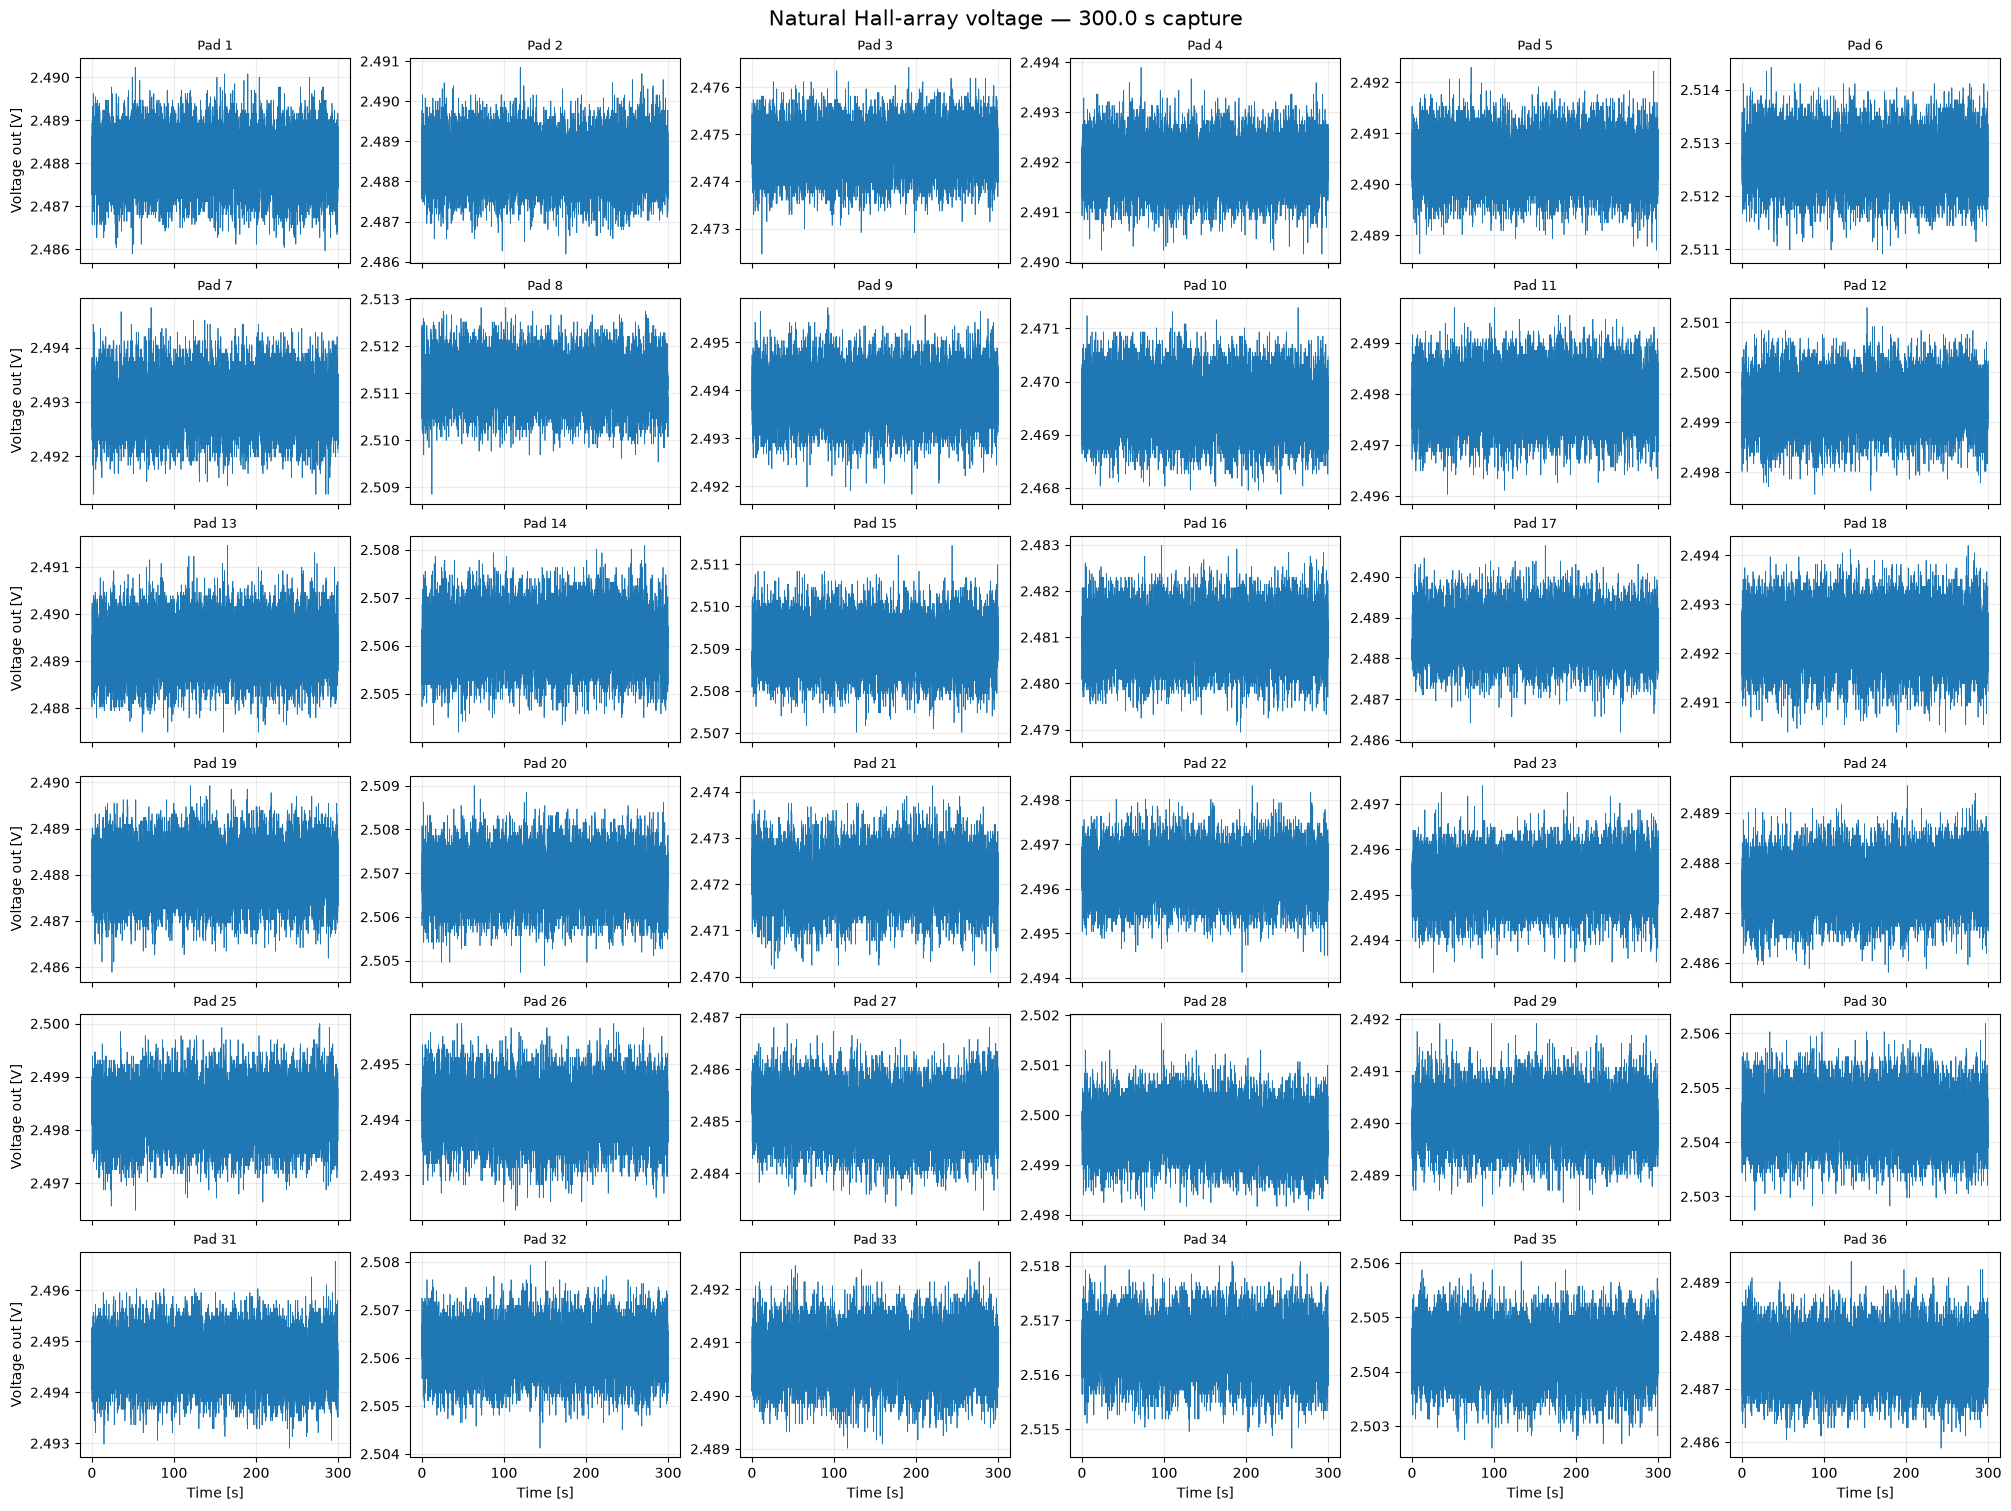

Saved hall_array_output/20260914T033112Z/voltage_out_36_pads_5min.png


In [4]:
fig, axes = plt.subplots(6, 6, figsize=(20, 15), sharex=True, constrained_layout=True)
for channel, ax in enumerate(axes.flat):
    ax.plot(time_s, voltage_out[:, channel], linewidth=0.55)
    ax.set_title(f"Pad {channel + 1}", fontsize=9)
    ax.grid(True, alpha=0.25)
    ax.ticklabel_format(axis="y", style="sci", scilimits=(-3, 3))
    if channel // 6 == 5:
        ax.set_xlabel("Time [s]")
    if channel % 6 == 0:
        ax.set_ylabel("Voltage out [V]")

fig.suptitle(
    f"Natural Hall-array voltage — {capture_elapsed_s:.1f} s capture",
    fontsize=15,
)
timeseries_plot_path = OUTPUT_DIR / "voltage_out_36_pads_5min.png"
fig.savefig(timeseries_plot_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved {timeseries_plot_path}")

### Natural voltage comparison in one time-series plot

This plot overlays the natural output voltage of all 36 pads, including their stable approximately 2.5 V offsets.

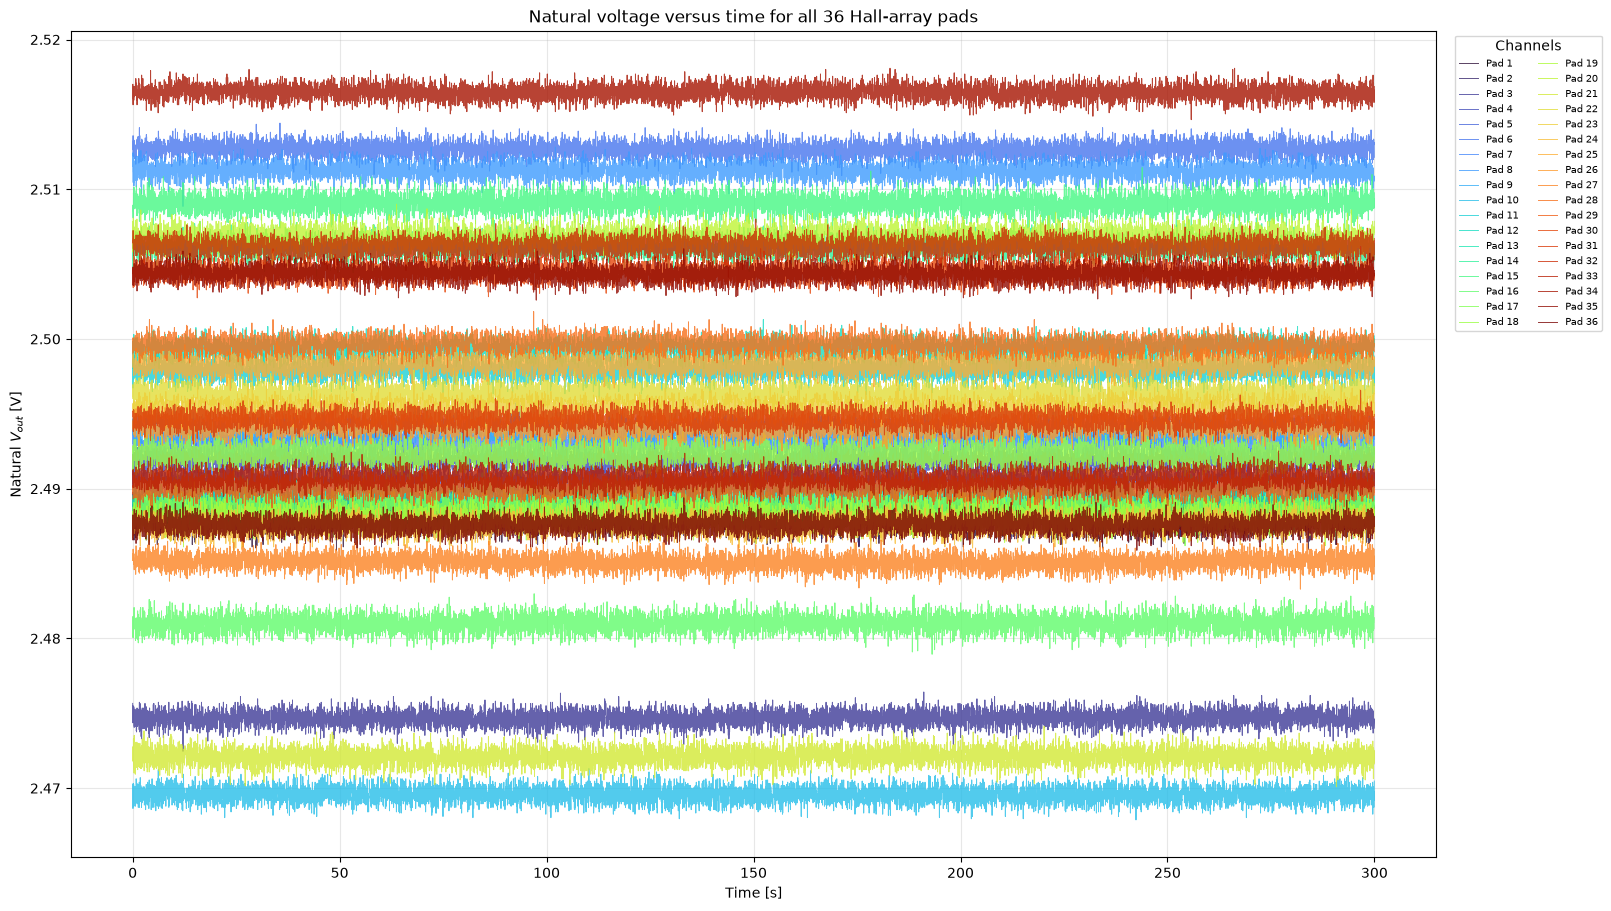

Saved hall_array_output/20260914T033112Z/natural_voltage_all_36_pads_timeseries.png


In [5]:
# Plot the natural output voltage of all 36 pads on one set of axes.
fig, ax = plt.subplots(figsize=(16, 9), constrained_layout=True)
colors = plt.cm.turbo(np.linspace(0.0, 1.0, NUM_CHANNELS))
for channel, color in enumerate(colors):
    ax.plot(
        time_s,
        voltage_out[:, channel],
        color=color,
        linewidth=0.7,
        alpha=0.8,
        label=f"Pad {channel + 1}",
    )

ax.set_xlabel("Time [s]")
ax.set_ylabel(r"Natural $V_{out}$ [V]")
ax.set_title("Natural voltage versus time for all 36 Hall-array pads")
ax.grid(True, alpha=0.3)
ax.legend(title="Channels", bbox_to_anchor=(1.01, 1.0), loc="upper left", ncol=2, fontsize=7)

actual_voltage_plot_path = OUTPUT_DIR / "natural_voltage_all_36_pads_timeseries.png"
fig.savefig(actual_voltage_plot_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved {actual_voltage_plot_path}")

## 5. Ensemble average of all 36 pads

At every time point, the ensemble output is the equal-weight arithmetic mean of the 36 simultaneous natural pad voltages. This is an average across pads, not a moving average across time.

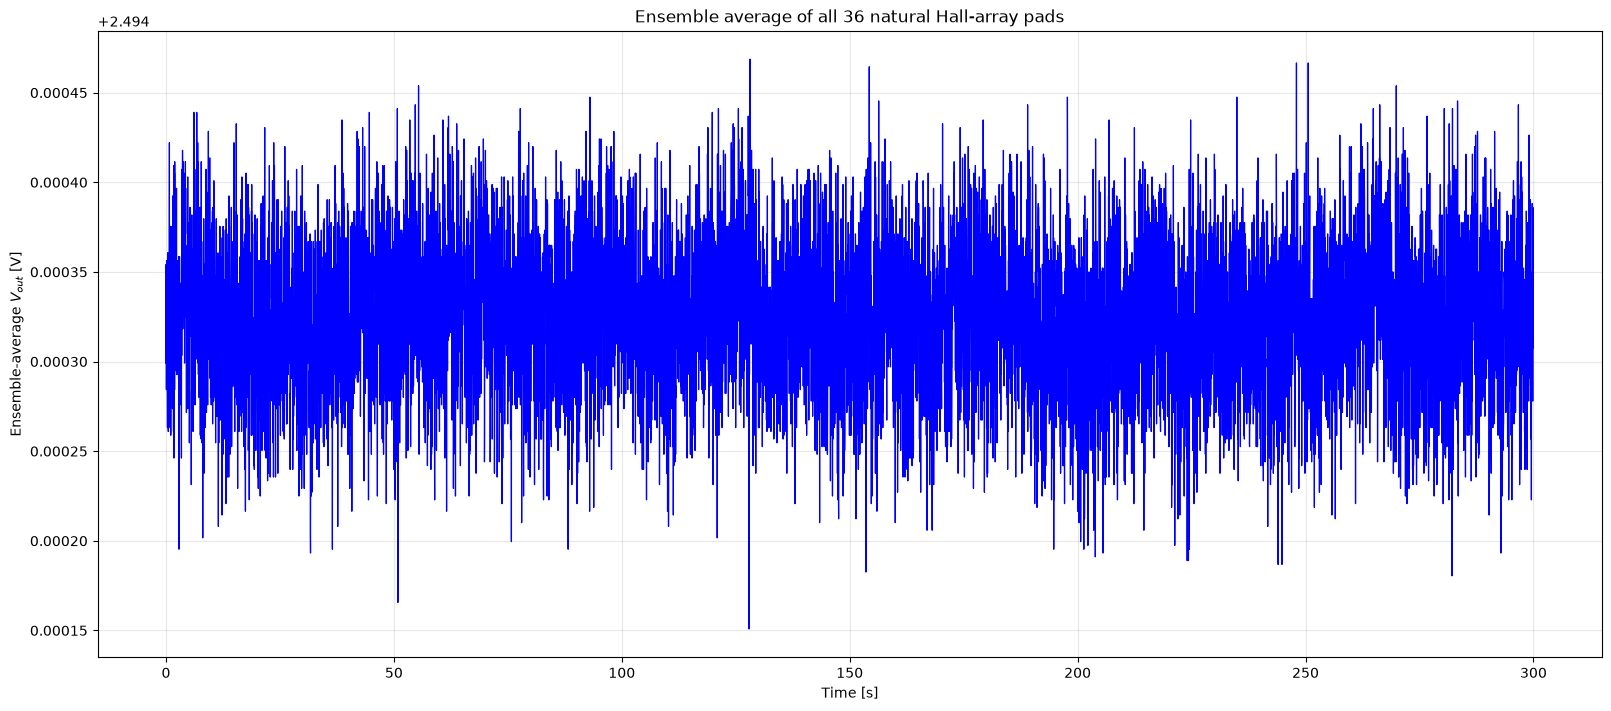

Ensemble mean: 2.494324 V
Saved hall_array_output/20260914T033112Z/ensemble_average_36_pads.csv
Saved hall_array_output/20260914T033112Z/ensemble_average_36_pads.npz
Saved hall_array_output/20260914T033112Z/ensemble_average_36_pads.png


In [6]:
# Ensemble average across the 36 pads for every acquired frame.
ensemble_average_v = voltage_out.mean(axis=1)

# Save the exact time and ensemble-average values used in the plot.
ensemble_csv_path = OUTPUT_DIR / "ensemble_average_36_pads.csv"
ensemble_table = np.column_stack((time_s, ensemble_average_v))
np.savetxt(
    ensemble_csv_path,
    ensemble_table,
    delimiter=",",
    header="time_s,ensemble_average_voltage_v",
    comments="",
)

ensemble_npz_path = OUTPUT_DIR / "ensemble_average_36_pads.npz"
np.savez_compressed(
    ensemble_npz_path,
    time_s=time_s,
    ensemble_average_voltage_v=ensemble_average_v,
)

fig, ax = plt.subplots(figsize=(16, 7), constrained_layout=True)
ax.plot(time_s, ensemble_average_v, color="blue", linewidth=0.9)
ax.set_xlabel("Time [s]")
ax.set_ylabel(r"Ensemble-average $V_{out}$ [V]")
ax.set_title("Ensemble average of all 36 natural Hall-array pads")
ax.grid(True, alpha=0.3)

ensemble_plot_path = OUTPUT_DIR / "ensemble_average_36_pads.png"
fig.savefig(ensemble_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Ensemble mean: {ensemble_average_v.mean():.6f} V")
print(f"Saved {ensemble_csv_path}")
print(f"Saved {ensemble_npz_path}")
print(f"Saved {ensemble_plot_path}")

## 6. PSD of the natural 36-pad ensemble average

This cell plots power spectral density in V²/Hz versus frequency for the ensemble average of the natural pad voltages.

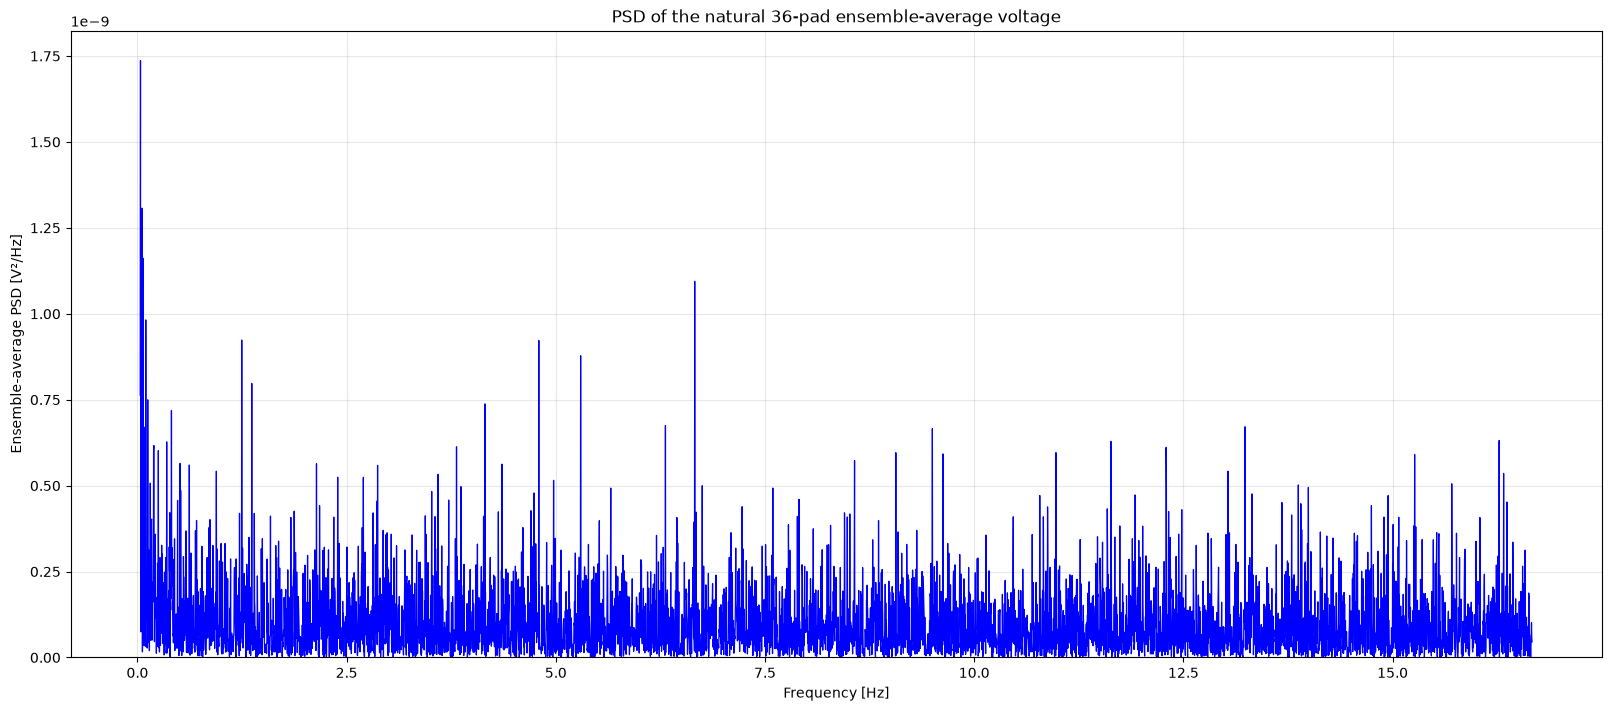

Saved hall_array_output/20260914T033112Z/ensemble_average_psd.csv
Saved hall_array_output/20260914T033112Z/ensemble_average_psd.npz
Saved hall_array_output/20260914T033112Z/ensemble_average_psd.png


In [15]:
# Use the natural ensemble-average voltage without DC removal.
ensemble_signal_v = ensemble_average_v
ensemble_sample_count = len(ensemble_signal_v)
ensemble_frequency_hz = np.fft.rfftfreq(
    ensemble_sample_count, d=1.0 / sample_rate_hz
)
ensemble_fft = np.fft.rfft(ensemble_signal_v)
ensemble_psd_v2_per_hz = (np.abs(ensemble_fft) ** 2) / (
    sample_rate_hz * ensemble_sample_count
)

# Convert to a one-sided PSD. DC and Nyquist are not doubled.
if ensemble_sample_count % 2 == 0:
    ensemble_psd_v2_per_hz[1:-1] *= 2.0
else:
    ensemble_psd_v2_per_hz[1:] *= 2.0
ensemble_psd_v2_per_hz = np.maximum(ensemble_psd_v2_per_hz, 0.0)

# Save exactly the same frequency and V²/Hz values used in the plot.
ensemble_psd_csv_path = OUTPUT_DIR / "ensemble_average_psd.csv"
np.savetxt(
    ensemble_psd_csv_path,
    np.column_stack((ensemble_frequency_hz, ensemble_psd_v2_per_hz)),
    delimiter=",",
    header="frequency_hz,ensemble_average_psd_v2_per_hz",
    comments="",
)

ensemble_psd_npz_path = OUTPUT_DIR / "ensemble_average_psd.npz"
np.savez_compressed(
    ensemble_psd_npz_path,
    frequency_hz=ensemble_frequency_hz,
    ensemble_average_psd_v2_per_hz=ensemble_psd_v2_per_hz,
    signal_contains_dc=np.array(True),
)

fig, ax = plt.subplots(figsize=(16, 7), constrained_layout=True)
ax.plot(ensemble_frequency_hz[10:], ensemble_psd_v2_per_hz[10:], color="blue", linewidth=0.9)
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel(r"Ensemble-average PSD [V²/Hz]")
ax.set_ylim(bottom=0.0)
ax.set_title("PSD of the natural 36-pad ensemble-average voltage")
ax.grid(True, alpha=0.3)

ensemble_psd_plot_path = OUTPUT_DIR / "ensemble_average_psd.png"
fig.savefig(ensemble_psd_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved {ensemble_psd_csv_path}")
print(f"Saved {ensemble_psd_npz_path}")
print(f"Saved {ensemble_psd_plot_path}")

## 7. Calculate PSD for all 36 natural pad voltages

The natural pad voltages are used directly for the individual-channel PSD calculation. The 0 Hz component therefore includes the stable board-voltage offset.

In [8]:
# Use the natural board-voltage samples directly; no DC removal or filtering.
voltage_for_psd_v = voltage_out
print("Using natural board-voltage samples; no DC removal or filtering.")

Using natural board-voltage samples; no DC removal or filtering.


In [9]:
# Calculate a one-sided PSD directly from the complete natural-voltage recording.
# This is a single FFT periodogram: no Welch/segment averaging or smoothing.
number_of_samples = len(voltage_for_psd_v)
psd_frequency_hz = np.fft.rfftfreq(number_of_samples, d=1.0 / sample_rate_hz)
voltage_fft = np.fft.rfft(voltage_for_psd_v, axis=0)
psd_v2_per_hz = (np.abs(voltage_fft) ** 2) / (sample_rate_hz * number_of_samples)

# Convert the two-sided result to a one-sided PSD. DC and Nyquist are not doubled.
if number_of_samples % 2 == 0:
    psd_v2_per_hz[1:-1] *= 2.0
else:
    psd_v2_per_hz[1:] *= 2.0
psd_v2_per_hz = np.maximum(psd_v2_per_hz, 0.0)

# Save the exact same frequency and PSD arrays used by the plot below.
psd_csv_path = OUTPUT_DIR / "psd_36_pads.csv"
psd_table = np.column_stack((psd_frequency_hz, psd_v2_per_hz))
psd_header = "frequency_hz," + ",".join(
    f"pad_{index:02d}_psd_v2_per_hz" for index in range(1, NUM_CHANNELS + 1)
)
np.savetxt(psd_csv_path, psd_table, delimiter=",", header=psd_header, comments="")

psd_npz_path = OUTPUT_DIR / "psd_36_pads.npz"
np.savez_compressed(
    psd_npz_path,
    frequency_hz=psd_frequency_hz,
    psd_v2_per_hz=psd_v2_per_hz,
    signal_contains_dc=np.array(True),
    sample_rate_hz=np.array(sample_rate_hz),
    estimator=np.array("single FFT PSD of natural voltage; no DC removal or averaging"),
)

print(f"Frequency-bin spacing: {psd_frequency_hz[1] - psd_frequency_hz[0]:.6g} Hz")
print(f"Saved {psd_csv_path}")
print(f"Saved {psd_npz_path}")

Frequency-bin spacing: 0.00333336 Hz
Saved hall_array_output/20260914T033112Z/psd_36_pads.csv
Saved hall_array_output/20260914T033112Z/psd_36_pads.npz


## 8. Plot PSD for all 36 pads

This plot overlays the saved PSD of all 36 pads. Its unit is V²/Hz and it includes the natural stable DC voltage at 0 Hz.

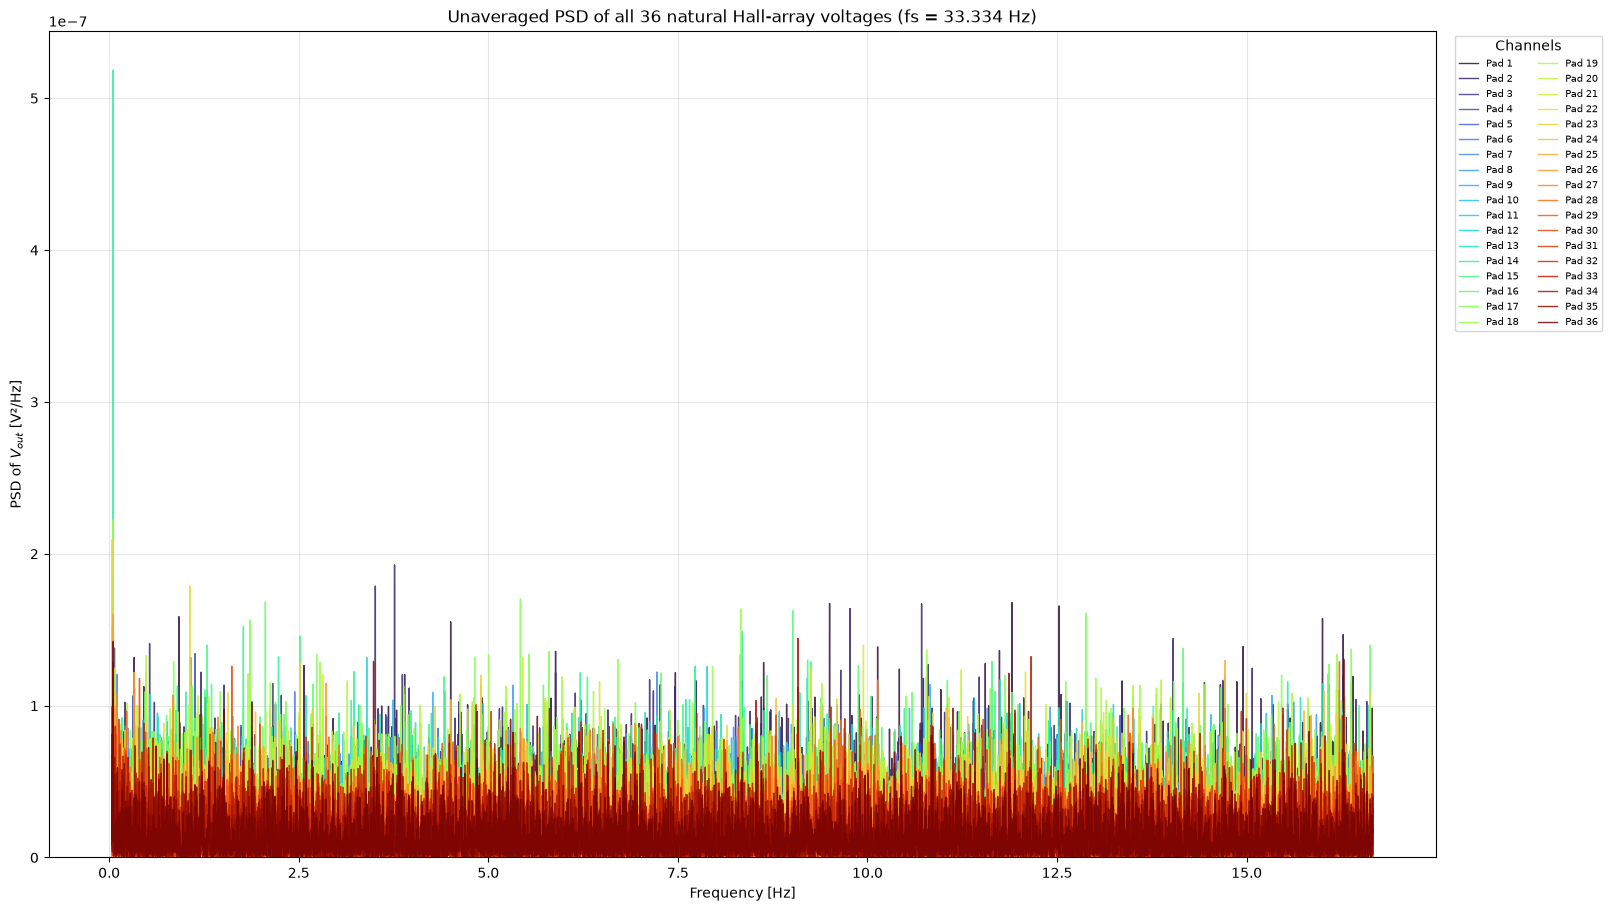

Saved hall_array_output/20260914T033112Z/psd_36_pads.png


In [16]:
# Plot the PSD arrays saved by the preceding cell.
fig, ax = plt.subplots(figsize=(16, 9), constrained_layout=True)
colors = plt.cm.turbo(np.linspace(0.0, 1.0, NUM_CHANNELS))
for channel, color in enumerate(colors):
    ax.plot(
        psd_frequency_hz[10:],
        psd_v2_per_hz[10:, channel],
        color=color,
        linewidth=1.0,
        alpha=0.85,
        label=f"Pad {channel + 1}",
    )

ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel(r"PSD of $V_{out}$ [V²/Hz]")
ax.set_ylim(bottom=0.0)
ax.set_title(f"Unaveraged PSD of all 36 natural Hall-array voltages (fs = {sample_rate_hz:.3f} Hz)")
ax.grid(True, alpha=0.3)
ax.legend(title="Channels", bbox_to_anchor=(1.01, 1.0), loc="upper left", ncol=2, fontsize=7)

psd_plot_path = OUTPUT_DIR / "psd_36_pads.png"
fig.savefig(psd_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved {psd_plot_path}")

## Output files

Each run creates a UTC timestamped directory under `hall_array_output/` containing:

- `hall_array_5min_unfiltered.npz`: lossless primary acquisition data
- `hall_array_5min_unfiltered.csv`: time and 36 voltage channels
- `voltage_out_36_pads_5min.png`: individual natural-voltage time-series plots
- `natural_voltage_all_36_pads_timeseries.png`: all natural-voltage traces overlaid
- `ensemble_average_36_pads.csv`, `.npz`, and `.png`: mean of all 36 natural pad voltages versus time
- `ensemble_average_psd.csv`, `.npz`, and `.png`: ensemble PSD in V²/Hz, including DC
- `psd_36_pads.npz`, `.csv`, and `.png`: natural-voltage PSD results in V²/Hz, including DC
- `metadata.json`: acquisition and processing settings